#**Regression Course**


---

In this course, you will learn how to apply ***the supervised learning workflow (explained in Section 4 of the lecture) to regression problems***. We will use **linear regression model** throughout the exercises and look at each step of the workflow: ***understanding the data, processing data, model building, and model evaluation***.The goal is to practice the knowledge required for each step depending on the level.

#Level３（★★★☆）


---
In Level 3, you will train a model and make predictions using the data with outliers removed, based on the scatter plot.

##3.1. Preprocessing Data


As always, download `Car_Price_Data.csv` using the link below, upload it to the designated location, load it into a DataFrame, and remove any missing values.


[Car_Price_Data.csv](https://drive.google.com/file/d/1YVQgy_jAwSVH5YEMdWlrTzkXEf7no860/view?usp=drive_link)

In [ ]:
import pandas as pd

df = pd.read_csv('Car_Price_Data.csv')
df = df.dropna()

In Level 2, we focused on detecting outliers by examining individual variables using a boxplot, identifying six outliers.

Now in Level 3, we shift our focus to identifying outliers visually using scatter plots.

Let’s begin by revisiting the scatter plot of `engine-size` versus `price` that we explored in Level 1.
In the scatter plot (left graph), the orange points correspond to the data identified as outliers as we saw in Level 2.


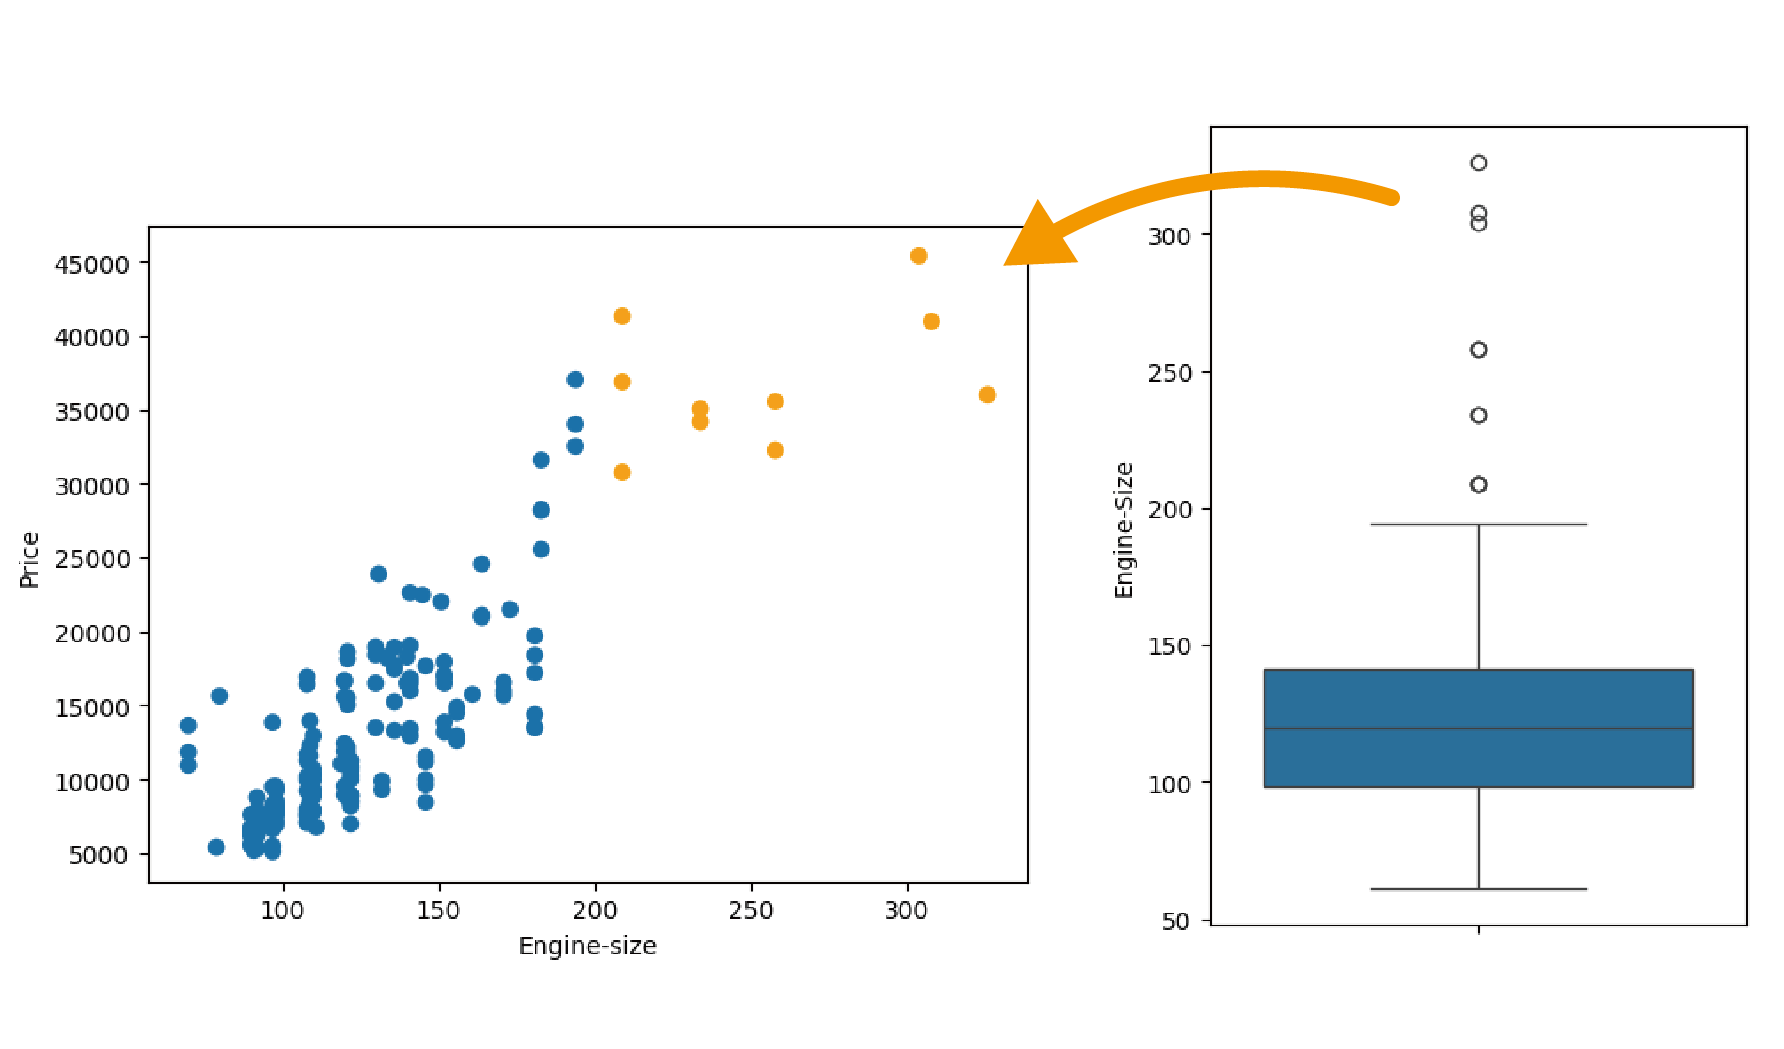

Unlike the boxplot approach to finding outliers, scatter plot method does not rely on strict formulas or clearly defined thresholds. Instead, it depends on visual judgment, meaning interpretations may vary from person to person.

For instance, whether the red-circled points in the figure below are considered outliers is subjective. In this lecture, we will not treat these points as outliers.



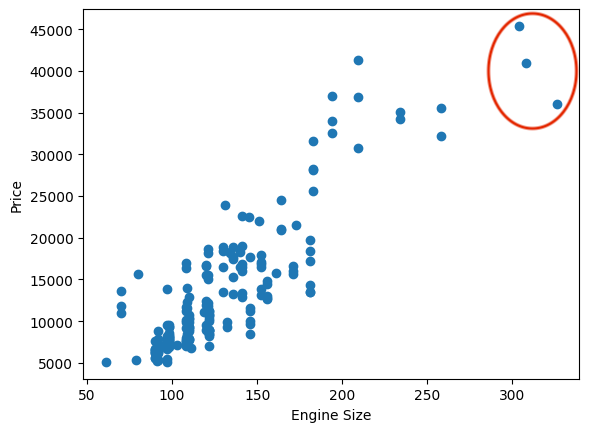

Next, we will look at the scatter plot of `city-mpg` versus `price`. The red-circled data points seem to follow a slightly different trend from the overall pattern.

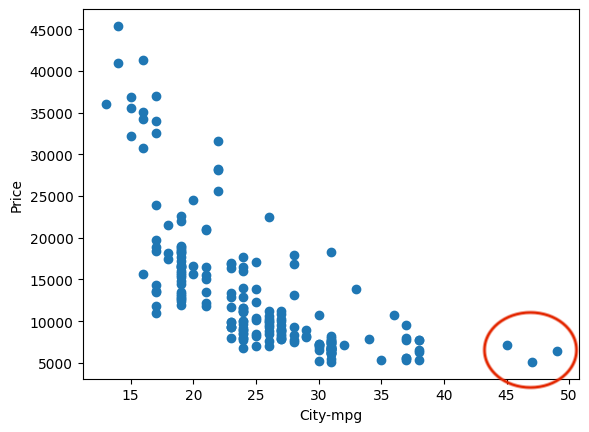

From the scatter plot, we can see that all of these points have a `city-mpg` value of 40 or higher, so we will exclude them from the dataset.

This time, we want to keep only the data where the `city-mpg` value is 40 or less. As we did in Level 2, you can use a comparison operator to set this condition, as shown below.


In [ ]:
is_under_40 = df['city-mpg'] <= 40
df = df[is_under_40]

Let’s check whether the target data points have actually been removed. We’ll create a scatter plot to confirm.

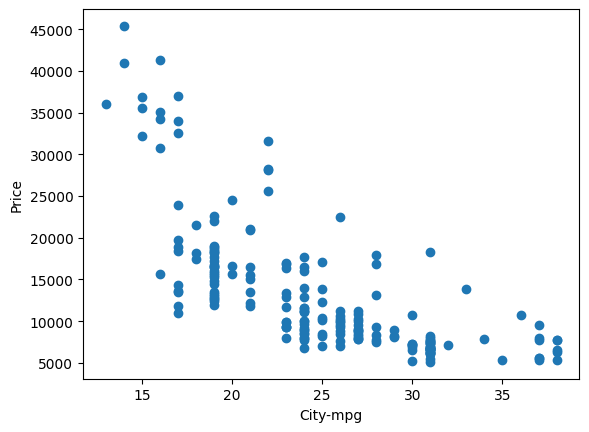

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['city-mpg'], df['price'])
plt.xlabel('City-mpg')
plt.ylabel('Price')
plt.show()

The red-circled area has been successfully removed, resulting in a more consistent overall distribution.

Next, we will check the scatter plot of `curb-weight` and `price`. Here too, the red-circled data points appear to follow a slightly different trend from the overall pattern.

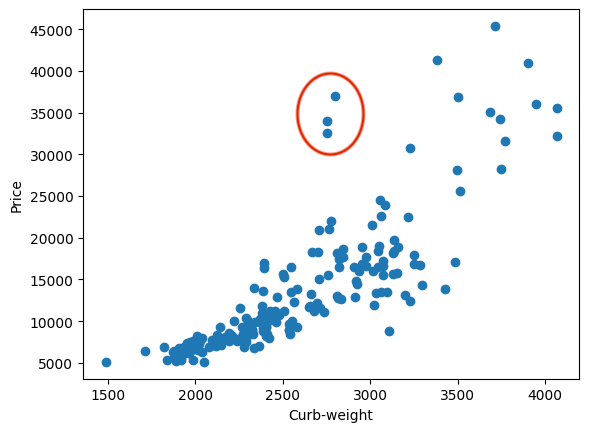

This time, compared to the `city-mpg` case, the outliers are in slightly more complex positions. Let’s consider a condition that applies only to these three specific data points.

We can determine that the condition applying only to the outliers is:

`curb-weight` is 3000 or less, and `price` is 30,000 or more.


As we learned in level 2, to apply multiple conditions, you can use the following symbols:

| Variable | Definiton |
|------|------|
| ＆ | and |
| ｜ | or |
| ～ | not |

First, let us extract only the data points that meet the condition for outliers.

In [ ]:
df_out = df[(df['curb-weight'] <= 3000) & (df['price'] >= 30000)]

Let’s check whether exactly three data points matching the condition have been correctly extracted.

In [ ]:
df_out

,engine-size,city-mpg,curb-weight,price
126,194,17,2756,32528.0
127,194,17,2756,34028.0
128,194,17,2800,37028.0



We can see that df_out contains the data points where `curb-weight` is 3000 or less and `price` is 30,000 or more.
However, since we actually want to keep the data excluding the outliers, this time we'll add “not” (~) in front of the entire condition.

In [ ]:
df = df[~((df['curb-weight'] <= 3000) & (df['price'] >= 30000))]

At this point, only the data excluding the outliers should remain. Let’s check whether the intended data points have been successfully removed.

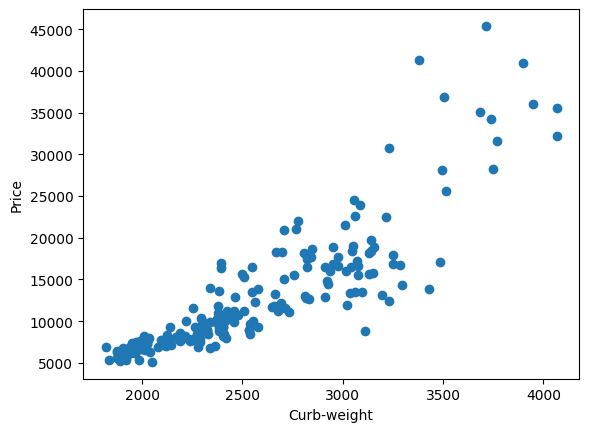

In [ ]:
plt.scatter(df['curb-weight'], df['price'])
plt.xlabel('Curb-weight')
plt.ylabel('Price')
plt.show()

As always, we will divide the data into **Explanatory variable** and **Target variable**.


In [ ]:
X = df.drop('price', axis=1)
y = df['price']

##3.2. Model Building and Evaluation

The training process is the same as before.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=0)

scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print('R² score for each split:', scores)
print('Average R² score from cross-validation:', scores.mean())


各分割における決定係数: [0.88490776 0.69096002 0.80572898 0.79117215 0.82898366]
クロスバリデーションの平均決定係数: 0.8003505157565154


After removing outliers using the scatter plot, the average R² increased compared to Level 1 (no outlier processing) and Level 2 (outliers removed using box plots).
This shows that the impact of outlier processing on model accuracy can vary from case to case.
And this doesn’t apply only to outlier removal—trying different approaches is essential for improving model accuracy.

##3.3. Practice Problems


**Q3-1.** Download the `Regression_Lv3_Practice.csv` from the link below, upload the file, and load it as a pandas DataFrame.
Then display the first 5 rows to check the data.

[Regression_Lv3_Practice.csv](https://drive.google.com/file/d/1vIha3Pn9FAa4OWuGLjpP-VL1Bns9dK_e/view?usp=drive_link)


**Q3-2.** Using the DataFrame loaded from Q3-1, create a scatter plot with `engine-size` on the x-axis and `price` on the y-axis.

**Q3-3.**
Remove the outliers in the area circled in red in the figure.

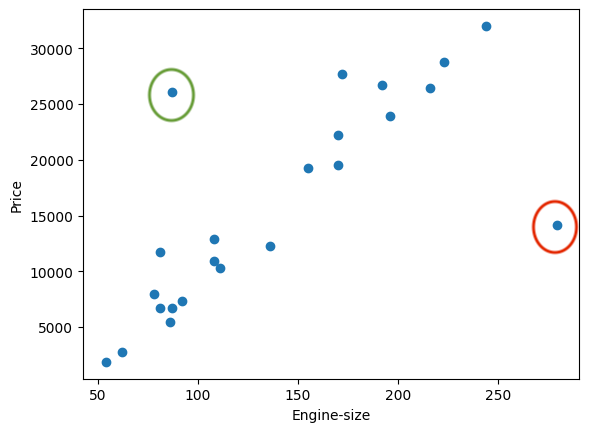

**Q3-4.** Remove the outliers in the area circled in green in the figure from Q3-3.